# Benchmark model performance

This notebooks benchmarks the available predictive models on sequence data.

In [1]:
import collections
import itertools
import os

import IPython.display as ipy_display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
import torch
from nettcr.models import NetTCR
from scipy import stats
from sklearn import metrics

from tcr_antigen_prediction.models import TCRStructMap

In [2]:
TAB = '&nbsp;&nbsp;&nbsp;&nbsp;'

In [3]:
sequences = pd.read_csv('data/interim/sequences_pMHC_split.csv', index_col='index')

In [4]:
predictions = []

for path in (
    'data/processed/TCRStructMap_predictions_on_sequences_pMHC_split.csv',
    'data/processed/TCRStructMap_sequence_only_predictions_on_sequences_pMHC_split.csv',
    'data/processed/NetTCR_predictions_on_sequences_pMHC_split.csv',
):
    model_name = os.path.basename(path).replace('_predictions_on_sequences_pMHC_split.csv', '')
    model_predictions = pd.read_csv(path)
    model_predictions['model_name'] = model_name

    predictions.append(model_predictions)

predictions = pd.concat(predictions).reset_index(drop=True)

predictions = predictions.merge(sequences, how='left', left_on='index', right_index=True)
predictions = predictions[predictions['fold'] == predictions['sub_model_number']].reset_index(drop=True)

In [5]:
def model_name_sort_key(name: str) -> tuple[str, str]:
    return (-ord(name[0]), name)

In [6]:
with open('data/interim/peptides.txt') as fh:
    peptide_key = np.array(fh.read().rstrip().split('\n'))

peptide_distances = np.loadtxt('data/interim/peptide_distances.txt', dtype=int)

In [7]:
def get_minimum_peptide_distance(peptide: str, training_peptides: np.ndarray) -> int:
    if peptide not in peptide_key:
        return np.nan

    training_key_idxs = np.where(np.isin(peptide_key, training_peptides))[0]
    peptide_index = np.where(peptide == peptide_key)[0][0]

    return np.min(peptide_distances[peptide_index][training_key_idxs])

In [8]:
peptide_folds = predictions[['peptide', 'fold']].drop_duplicates()
peptide_folds['min_peptide_distance'] = peptide_folds.apply(
    lambda row: get_minimum_peptide_distance(
        row.peptide,
        sequences[sequences['fold'] != row.fold]['peptide'].unique(),
    ),
    axis=1,
)

In [9]:
predictions = predictions.merge(peptide_folds, how='left', on=['peptide', 'fold'])

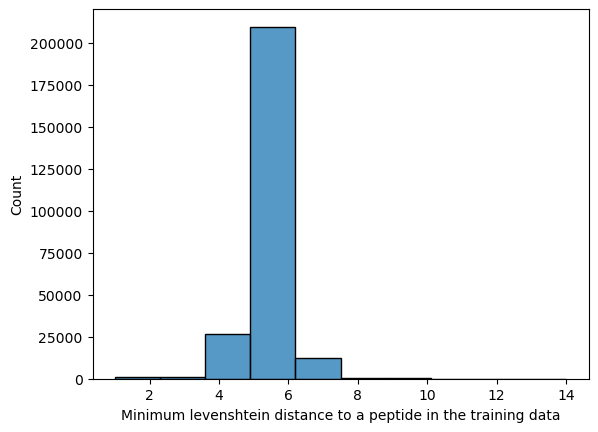

In [10]:
sns.histplot(predictions, x='min_peptide_distance', bins=10)

plt.xlabel('Minimum levenshtein distance to a peptide in the training data')
plt.show()

In [11]:
predictions['fold'] = predictions['fold'].astype(str)

## Model Size

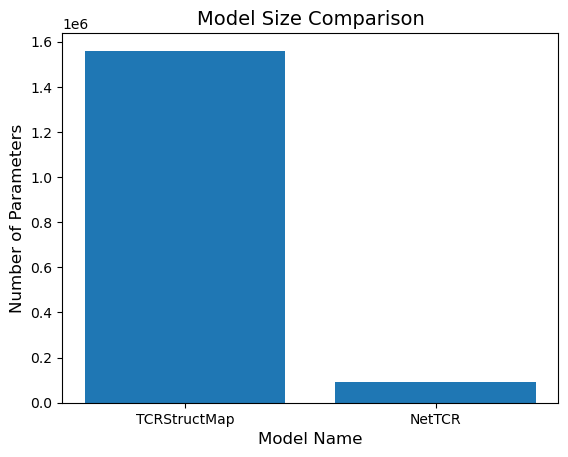

In [12]:
def count_parameters(model: torch.nn.Module) -> int:
    """Count the number of parmeters in a pytorch model."""
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


plt.bar(x=['TCRStructMap', 'NetTCR'], height=[count_parameters(model) for model in (TCRStructMap(), NetTCR())])

plt.title('Model Size Comparison', fontsize=14)
plt.xlabel('Model Name', fontsize=12)
plt.ylabel('Number of Parameters', fontsize=12)

plt.show()

## ROC

In [13]:
roc_results = predictions.groupby(['model_name']).apply(
    lambda group: metrics.roc_curve(group['label'], group['prediction']),
    include_groups=False,
)
roc_results.name = 'roc_curve'
roc_results = roc_results.reset_index()

In [14]:
roc_01_results = predictions.groupby(['model_name']).apply(
    lambda group: metrics.roc_auc_score(group['label'], group['prediction'], max_fpr=0.1),
    include_groups=False,
)
roc_01_results.name = 'roc_auc_01'
roc_01_results = roc_01_results.reset_index()

roc_results = roc_results.merge(roc_01_results, on=['model_name'], how='inner')

In [15]:
roc_results[['fpr', 'tpr', 'threshold']] = roc_results['roc_curve'].apply(pd.Series)
roc_results['roc_auc'] = roc_results.apply(lambda row: metrics.auc(row['fpr'], row['tpr']), axis=1)

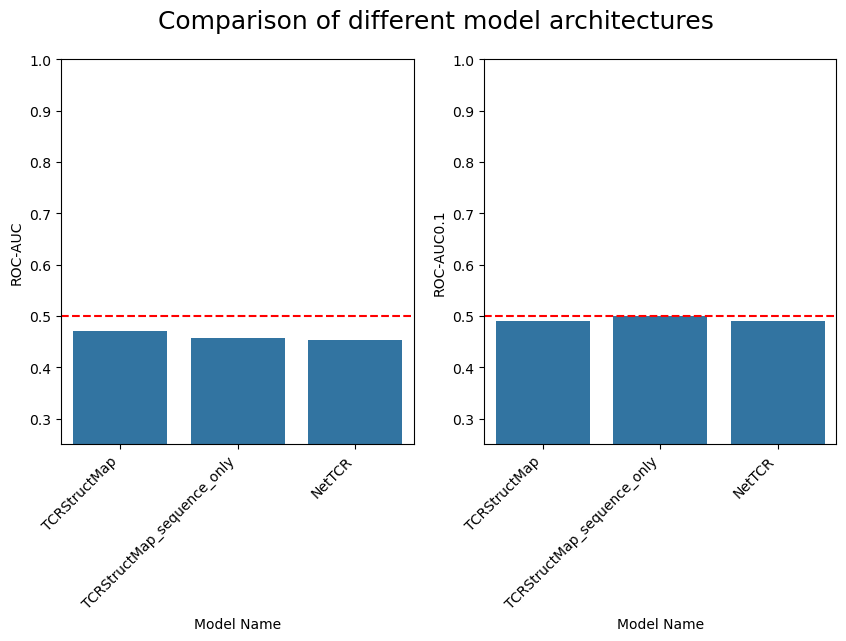

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

fig.suptitle('Comparison of different model architectures', fontsize=18)

for i, metric_name in enumerate(('roc_auc', 'roc_auc_01')):
    sns.barplot(
        roc_results,
        x='model_name',
        y=metric_name,
        order=sorted(roc_results['model_name'].unique(), key=model_name_sort_key),
        ax=axes[i],
    )

    axes[i].axhline(0.5, color='r', linestyle='dashed')

    axes[i].set_ylabel({'roc_auc': 'ROC-AUC', 'roc_auc_01': 'ROC-AUC0.1'}[metric_name])
    axes[i].set_xlabel('Model Name')

    axes[i].set_xticks(axes[i].get_xticks())
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')

    axes[i].set_ylim([0.25, 1.0])

plt.show()

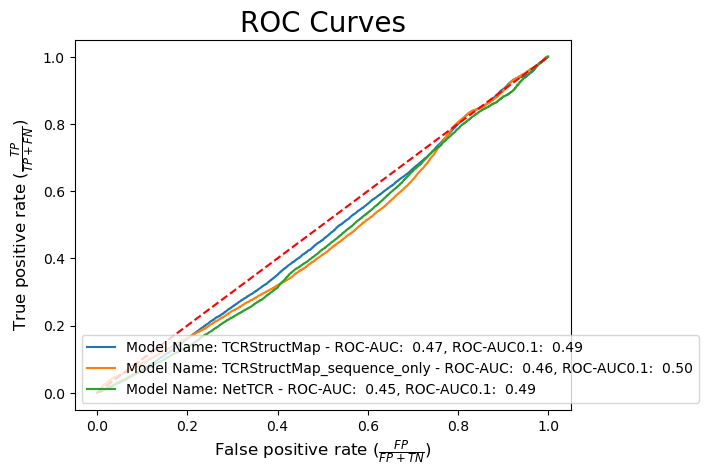

In [17]:
model_groups = roc_results.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=lambda name: (-ord(name[0]), name, len(name)))

plt.title('ROC Curves', fontsize=20)

for model_name in model_group_names:
    model_group = model_groups.get_group(model_name)

    roc_auc = model_group['roc_auc'].to_numpy()[0]
    roc_auc_01 = model_group['roc_auc_01'].to_numpy()[0]
    group = model_group.explode(['tpr', 'fpr'])

    plt.plot(
        group['fpr'],
        group['tpr'],
        label=f'Model Name: {model_name} - ROC-AUC: {roc_auc: .2f}, ROC-AUC0.1: {roc_auc_01: .2f}',
    )

plt.ylabel(r'True positive rate ($\frac{TP}{TP + FN}$)', fontsize=12)
plt.xlabel(r'False positive rate ($\frac{FP}{FP + TN}$)', fontsize=12)

plt.plot([0, 1], [0, 1], 'r--')
plt.legend()

plt.show()

In [18]:
roc_results_agg = roc_results[['model_name', 'roc_auc', 'roc_auc_01']]

roc_results_agg = roc_results_agg.sort_values('model_name', key=lambda col: col.map(model_name_sort_key))

roc_results_agg = roc_results_agg.rename(
    lambda column_name: column_name.title().replace('_', ' ').replace('Roc Auc', 'ROC-AUC').replace('01', '0.1'),
    axis='columns',
)

roc_results_agg = roc_results_agg.replace('TCRStructMap_sequence_only', f'{TAB}↳ Sequence Only')

roc_results_agg = roc_results_agg.set_index('Model Name')
roc_results_agg_styler = roc_results_agg.style
roc_results_agg_styler = roc_results_agg_styler.set_table_styles(
    [{'selector': '.row_heading', 'props': [('text-align', 'left')]}]
)
roc_results_agg_styler = roc_results_agg_styler.format(precision=2)
roc_results_agg_styler = roc_results_agg_styler.highlight_max(axis=0, props='font-weight: bold;')

roc_results_agg_styler

,ROC-AUC,ROC-AUC 0.1
Model Name,,
TCRStructMap,0.47,0.49
↳ Sequence Only,0.46,0.50
NetTCR,0.45,0.49


### Comparison of prediction results to mimimum distance between the peptides and the training set

In [19]:
roc_results_by_peptide_distance = predictions.groupby(['model_name', 'min_peptide_distance']).apply(
    lambda group: metrics.roc_auc_score(group['label'], group['prediction']),
    include_groups=False,
)
roc_results_by_peptide_distance.name = 'roc_auc'

roc_results_by_peptide_distance = roc_results_by_peptide_distance.reset_index()

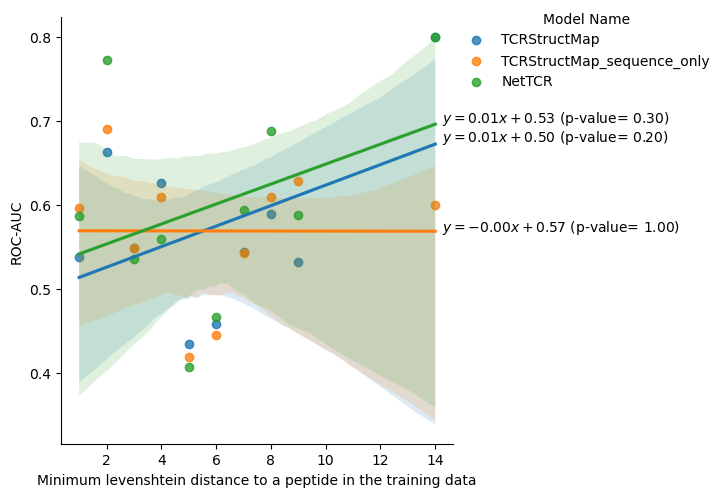

In [20]:
ax = sns.lmplot(
    roc_results_by_peptide_distance,
    x='min_peptide_distance',
    y='roc_auc',
    hue='model_name',
    hue_order=sorted(roc_results_by_peptide_distance['model_name'].unique(), key=model_name_sort_key),
)

for model_name in roc_results_by_peptide_distance['model_name'].unique():
    subset = roc_results_by_peptide_distance[roc_results_by_peptide_distance['model_name'] == model_name]
    slope, intercept, r_value, p_value, std_err = stats.linregress(subset['min_peptide_distance'], subset['roc_auc'])

    equation = f'$y = {slope:.2f}x + {intercept:.2f}$ (p-value={p_value: .2f})'

    x_pos = subset['min_peptide_distance'].max() + 0.25
    y_pos = slope * x_pos + intercept

    plt.text(x_pos, y_pos, equation, color='black')

ax.legend.set_title('Model Name')
ax.legend.set_loc('upper right')

plt.xlabel('Minimum levenshtein distance to a peptide in the training data')
plt.ylabel('ROC-AUC')

plt.show()

### Grouping ROC-AUC by Fold

In [21]:
roc_results_by_fold = predictions.groupby(['model_name', 'fold']).apply(
    lambda group: metrics.roc_curve(group['label'], group['prediction']),
    include_groups=False,
)
roc_results_by_fold.name = 'roc_curve'
roc_results_by_fold = roc_results_by_fold.reset_index()

In [22]:
roc_auc_01_results_by_fold = predictions.groupby(['model_name', 'fold']).apply(
    lambda group: metrics.roc_auc_score(group['label'], group['prediction'], max_fpr=0.1),
    include_groups=False,
)
roc_auc_01_results_by_fold.name = 'roc_auc_01'
roc_auc_01_results_by_fold = roc_auc_01_results_by_fold.reset_index()

roc_results_by_fold = roc_results_by_fold.merge(roc_auc_01_results_by_fold, on=['model_name', 'fold'], how='inner')

In [23]:
roc_results_by_fold[['fpr', 'tpr', 'threshold']] = roc_results_by_fold['roc_curve'].apply(pd.Series)

In [24]:
roc_results_by_fold['roc_auc'] = roc_results_by_fold.apply(lambda row: metrics.auc(row['fpr'], row['tpr']), axis=1)

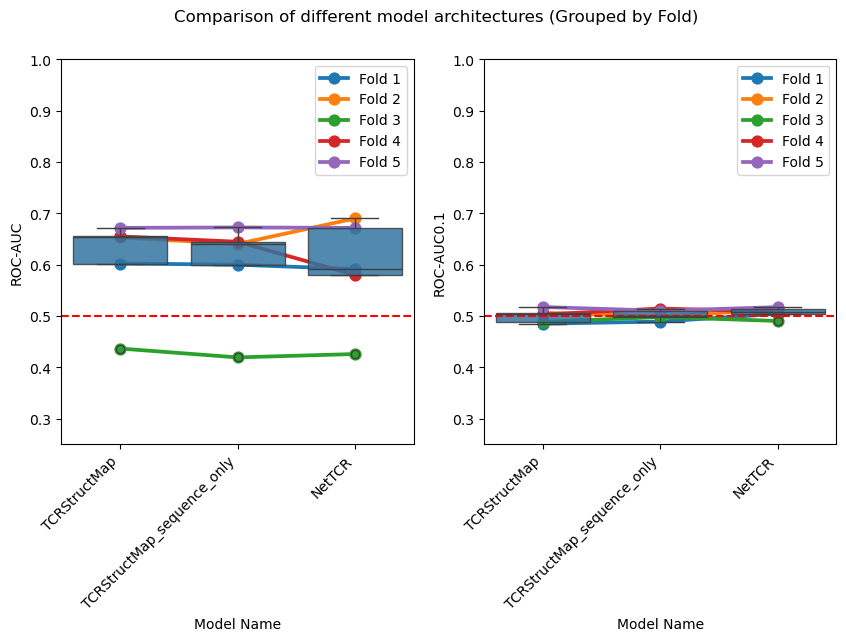

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

plt.suptitle('Comparison of different model architectures (Grouped by Fold)')

for i, metric_name in enumerate(('roc_auc', 'roc_auc_01')):
    sns.pointplot(
        roc_results_by_fold,
        x='model_name',
        y=metric_name,
        hue='fold',
        order=sorted(roc_results_by_fold['model_name'].unique(), key=model_name_sort_key),
        ax=axes[i],
    )

    sns.boxplot(
        roc_results_by_fold,
        x='model_name',
        y=metric_name,
        order=sorted(roc_results_by_fold['model_name'].unique(), key=model_name_sort_key),
        boxprops={'alpha': 0.85},
        color='C0',
        ax=axes[i],
    )

    axes[i].axhline(0.5, color='r', linestyle='dashed')

    axes[i].set_ylabel({'roc_auc': 'ROC-AUC', 'roc_auc_01': 'ROC-AUC0.1'}[metric_name])
    axes[i].set_xlabel('Model Name')

    axes[i].set_xticks(axes[i].get_xticks())
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')

    axes[i].set_ylim([0.25, 1.0])

    handles, labels = axes[i].get_legend_handles_labels()
    new_labels = [f'Fold {label}' for label in labels]
    axes[i].legend(handles, new_labels)

plt.show()

In [26]:
roc_results_by_fold_agg = roc_results_by_fold.groupby('model_name').agg(
    {'roc_auc': ['mean', 'median', 'std', 'count'], 'roc_auc_01': ['mean', 'median', 'std', 'count']}
)
roc_results_by_fold_agg = roc_results_by_fold_agg.loc[sorted(roc_results_by_fold_agg.index, key=model_name_sort_key)]
roc_results_by_fold_agg.index.name = roc_results_by_fold_agg.index.name.title().replace('_', ' ')

std_df = roc_results_by_fold_agg.xs('std', axis=1, level=1)
count_df = roc_results_by_fold_agg.xs('count', axis=1, level=1)

stderr_df = std_df / np.sqrt(count_df)
stderr_df.columns = pd.MultiIndex.from_product([stderr_df.columns, ['stderr']])

roc_results_by_fold_agg = pd.concat([roc_results_by_fold_agg, stderr_df], axis=1).sort_index(axis=1)
roc_results_by_fold_agg = roc_results_by_fold_agg.loc[:, roc_results_by_fold_agg.columns.get_level_values(1) != 'count']

roc_results_by_fold_agg_means = roc_results_by_fold_agg.xs('mean', axis=1, level=1)
roc_results_by_fold_agg_stderrs = roc_results_by_fold_agg.xs('stderr', axis=1, level=1)

roc_results_by_fold_agg = roc_results_by_fold_agg_means.combine(
    roc_results_by_fold_agg_stderrs, lambda mean, se: mean.map('{:.2f}'.format) + ' ± ' + se.map('{:.2e}'.format)
)

roc_results_by_fold_agg = roc_results_by_fold_agg[['roc_auc', 'roc_auc_01']].rename(
    lambda column_name: column_name.title().replace('_', ' ').replace('Roc Auc', 'ROC-AUC').replace('01', '0.1'),
    axis='columns',
)
roc_results_by_fold_agg = roc_results_by_fold_agg.rename({'TCRStructMap_sequence_only': f'{TAB}↳ Sequence Only'})

roc_results_by_fold_agg_styler = roc_results_by_fold_agg.style


def highlight_max(series: pd.Series, ref_vals: pd.Series) -> list[str]:
    is_max = series.index == ref_vals.idxmax()
    return ['font-weight: bold' if v else '' for v in is_max]


for col in roc_results_by_fold_agg.columns:
    column_name = col.lower().replace(' ', '_').replace('-', '_').replace('.', '')
    roc_results_by_fold_agg_styler = roc_results_by_fold_agg_styler.apply(
        highlight_max, ref_vals=roc_results_by_fold_agg_means[column_name], subset=[col]
    )

roc_results_by_fold_agg_styler = roc_results_by_fold_agg_styler.set_table_styles(
    [{'selector': '.row_heading', 'props': [('text-align', 'left')]}]
)

roc_results_by_fold_agg_styler

,ROC-AUC,ROC-AUC 0.1
Model Name,,
TCRStructMap,0.60 ± 4.34e-02,0.50 ± 5.96e-03
↳ Sequence Only,0.60 ± 4.55e-02,0.50 ± 4.56e-03
NetTCR,0.59 ± 4.67e-02,0.51 ± 4.62e-03


In [27]:
for metric_name in ('roc_auc', 'roc_auc_01'):
    print({'roc_auc': 'ROC-AUC', 'roc_auc_01': 'ROC-AUC0.1'}[metric_name])
    ipy_display.display(
        pg.friedman(roc_results_by_fold, dv=metric_name, within='model_name', subject='fold', method='f')
    )

    groups = list(roc_results_by_fold.set_index('fold').groupby('model_name')[metric_name])
    groups = sorted(groups, key=lambda group: model_name_sort_key(group[0]))
    groups = [(group_name, group.sort_index()) for group_name, group in groups]

    significance_level = 0.05 / len(groups)

    results = collections.defaultdict(list)
    for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
        stat, p_val = stats.wilcoxon(group1, group2, alternative='greater')

        results['group1'].append(group1_name)
        results['group2'].append(group2_name)
        results['stat'].append(stat)
        results['p_val'].append(p_val)
        results['signficant'].append(p_val < significance_level)

    ipy_display.display(pd.DataFrame(results))
    print()

ROC-AUC


,Source,W,ddof1,ddof2,F,p-unc
Friedman,model_name,0.12,1.6,6.4,0.545455,0.567201


,group1,group2,stat,p_val,signficant
0,TCRStructMap,TCRStructMap_sequence_only,14.0,0.06250,False
1,TCRStructMap,NetTCR,10.0,0.31250,False
2,TCRStructMap_sequence_only,NetTCR,9.0,0.40625,False



ROC-AUC0.1


,Source,W,ddof1,ddof2,F,p-unc
Friedman,model_name,0.16,1.6,6.4,0.761905,0.47663


,group1,group2,stat,p_val,signficant
0,TCRStructMap,TCRStructMap_sequence_only,5.0,0.78125,False
1,TCRStructMap,NetTCR,1.0,0.96875,False
2,TCRStructMap_sequence_only,NetTCR,4.0,0.84375,False


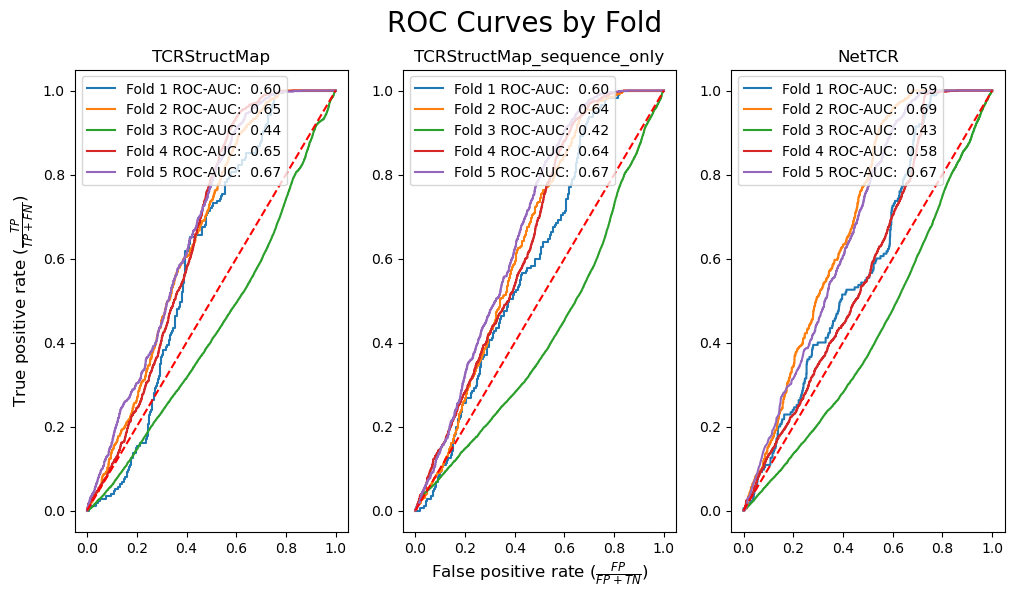

In [28]:
model_groups = roc_results_by_fold.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=lambda name: (-ord(name[0]), name, len(name)))

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('ROC Curves by Fold', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        roc_auc = fold_group['roc_auc'].to_numpy()[0]
        roc_auc_01 = fold_group['roc_auc_01'].to_numpy()[0]

        group = fold_group.explode(['tpr', 'fpr'])

        axes[i].plot(group['fpr'], group['tpr'], label=f'Fold {fold} ROC-AUC: {roc_auc: .2f}')

    if i == 0:
        axes[i].set_ylabel(r'True positive rate ($\frac{TP}{TP + FN}$)', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel(r'False positive rate ($\frac{FP}{FP + TN}$)', fontsize=12)

    axes[i].set_title(model_name)

    axes[i].plot([0, 1], [0, 1], 'r--')
    axes[i].legend()

In [29]:
model_groups = roc_results_by_fold.groupby('model_name')

fpr_interp = np.linspace(0, 1, 100)
tpr_interp = {}

for model_name, model_group in model_groups:
    tpr_interp[model_name] = {}
    for fold, fold_group in model_group.groupby('fold'):
        group = fold_group.explode(['tpr', 'fpr'])

        tpr_interp[model_name][fold] = np.interp(fpr_interp, group['fpr'].apply(float), group['tpr'].apply(float))

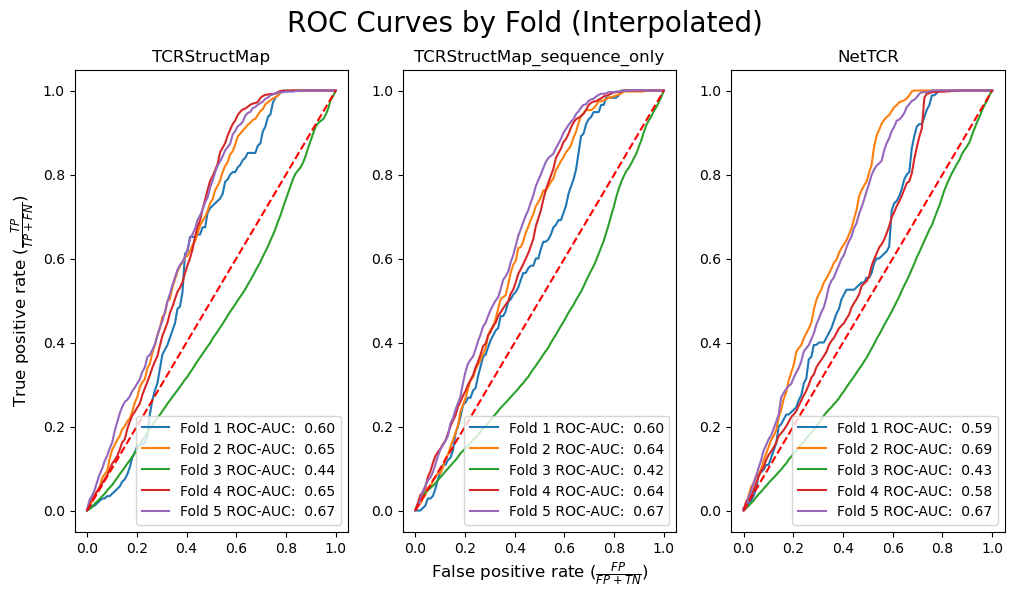

In [30]:
model_groups = roc_results_by_fold.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('ROC Curves by Fold (Interpolated)', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        roc_auc = fold_group['roc_auc'].to_numpy()[0]

        axes[i].plot(fpr_interp, tpr_interp[model_name][fold], label=f'Fold {fold} ROC-AUC: {roc_auc: .2f}')

    if i == 0:
        axes[i].set_ylabel(r'True positive rate ($\frac{TP}{TP + FN}$)', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel(r'False positive rate ($\frac{FP}{FP + TN}$)', fontsize=12)

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [0, 1], 'r--')
    axes[i].legend()

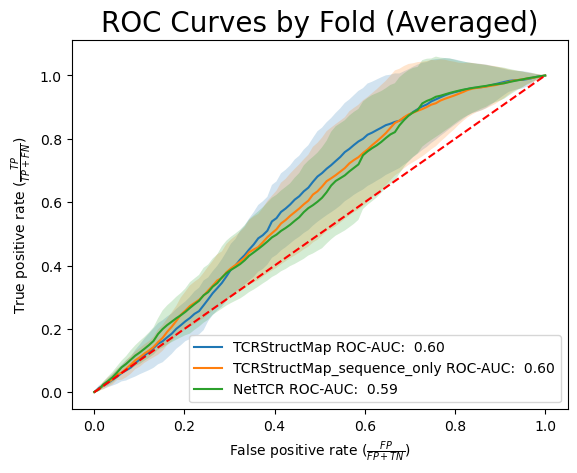

In [31]:
model_groups = roc_results_by_fold.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

for model_name in model_group_names:
    model_group = model_groups.get_group(model_name)

    tpr_mean = np.mean(np.array(list(tpr_interp[model_name].values())).T, axis=1)
    tpr_std = np.std(np.array(list(tpr_interp[model_name].values())).T, axis=1)

    roc_auc = metrics.auc(fpr_interp, tpr_mean)

    plt.plot(fpr_interp, tpr_mean, label=f'{model_name} ROC-AUC: {roc_auc: .2f}')
    plt.fill_between(fpr_interp, tpr_mean - tpr_std, tpr_mean + tpr_std, alpha=0.2)

plt.title('ROC Curves by Fold (Averaged)', fontsize=20)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel(r'False positive rate ($\frac{FP}{FP + TN}$)')
plt.ylabel(r'True positive rate ($\frac{TP}{TP + FN}$)')
plt.legend()

plt.show()

#### Comparison of prediction results to mimimum distance between the peptides and the training set

In [32]:
roc_results_by_fold_by_peptide_distance = predictions.groupby(['model_name', 'fold', 'min_peptide_distance']).apply(
    lambda group: metrics.roc_auc_score(group['label'], group['prediction']),
    include_groups=False,
)
roc_results_by_fold_by_peptide_distance.name = 'roc_auc'

roc_results_by_fold_by_peptide_distance = roc_results_by_fold_by_peptide_distance.reset_index()

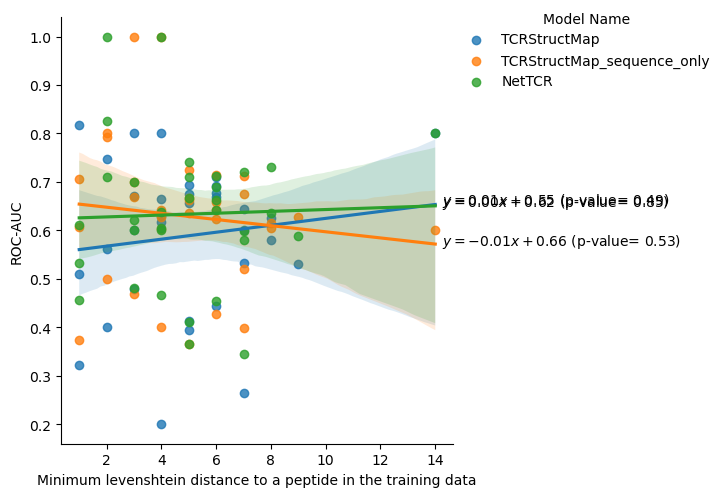

In [33]:
ax = sns.lmplot(
    roc_results_by_fold_by_peptide_distance,
    x='min_peptide_distance',
    y='roc_auc',
    hue='model_name',
    hue_order=sorted(roc_results_by_fold_by_peptide_distance['model_name'].unique(), key=model_name_sort_key),
)

for model_name in roc_results_by_fold_by_peptide_distance['model_name'].unique():
    subset = roc_results_by_fold_by_peptide_distance[
        roc_results_by_fold_by_peptide_distance['model_name'] == model_name
    ]
    slope, intercept, r_value, p_value, std_err = stats.linregress(subset['min_peptide_distance'], subset['roc_auc'])

    equation = f'$y = {slope:.2f}x + {intercept:.2f}$ (p-value={p_value: .2f})'

    x_pos = subset['min_peptide_distance'].max() + 0.25
    y_pos = slope * x_pos + intercept

    plt.text(x_pos, y_pos, equation, color='black')

ax.legend.set_title('Model Name')
ax.legend.set_loc('upper right')

plt.xlabel('Minimum levenshtein distance to a peptide in the training data')
plt.ylabel('ROC-AUC')

plt.show()

In [34]:
fold_peptide_distance_roc_aucs_lines = roc_results_by_fold_by_peptide_distance.groupby(['model_name', 'fold']).apply(
    lambda group: stats.linregress(group['min_peptide_distance'], group['roc_auc']),
    include_groups=False,
)

fold_peptide_distance_roc_aucs_lines.name = 'line'
fold_peptide_distance_roc_aucs_lines = fold_peptide_distance_roc_aucs_lines.reset_index()

fold_peptide_distance_roc_aucs_lines[['slope', 'intercept', 'r_value', 'p_value', 'std_err']] = (
    fold_peptide_distance_roc_aucs_lines['line'].apply(pd.Series)
)

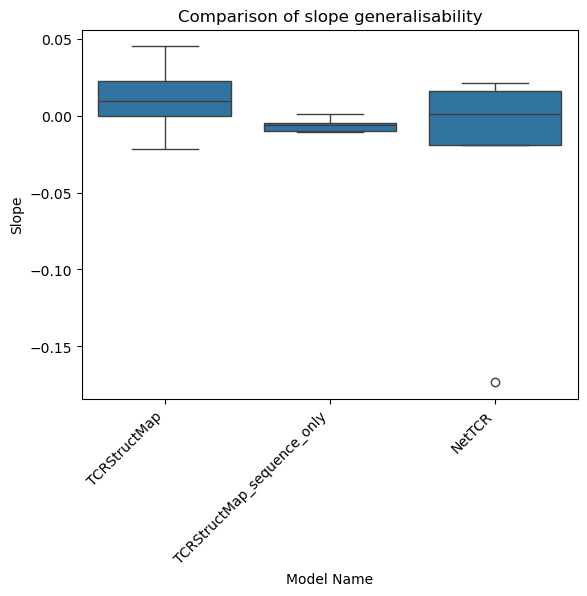

,mean,median,std
model_name,,,
TCRStructMap,0.010962,0.009243,0.024860
TCRStructMap_sequence_only,-0.006103,-0.006066,0.004783
NetTCR,-0.030903,0.000979,0.081187


In [35]:
sns.boxplot(
    fold_peptide_distance_roc_aucs_lines,
    x='model_name',
    y='slope',
    order=sorted(fold_peptide_distance_roc_aucs_lines['model_name'].unique(), key=model_name_sort_key),
)

plt.title('Comparison of slope generalisability')
plt.ylabel('Slope')
plt.xlabel('Model Name')
plt.xticks(rotation=45, ha='right')
plt.show()

fold_peptide_distance_roc_aucs_lines_agg = fold_peptide_distance_roc_aucs_lines.groupby('model_name')['slope'].agg(
    ['mean', 'median', 'std'],
)
fold_peptide_distance_roc_aucs_lines_agg = fold_peptide_distance_roc_aucs_lines_agg.loc[
    sorted(fold_peptide_distance_roc_aucs_lines_agg.index, key=model_name_sort_key)
]
fold_peptide_distance_roc_aucs_lines_agg

In [36]:
pg.friedman(fold_peptide_distance_roc_aucs_lines, dv='slope', within='model_name', subject='fold', method='f')

,Source,W,ddof1,ddof2,F,p-unc
Friedman,model_name,0.16,1.6,6.4,0.761905,0.47663


In [37]:
groups = list(fold_peptide_distance_roc_aucs_lines.set_index('fold').groupby('model_name')['slope'])
groups = sorted(groups, key=lambda group: model_name_sort_key(group[0]))
groups = [(group_name, group.sort_index()) for group_name, group in groups]

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.wilcoxon(group1, group2, alternative='greater')

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

,group1,group2,stat,p_val,signficant
0,TCRStructMap,TCRStructMap_sequence_only,13.0,0.09375,False
1,TCRStructMap,NetTCR,10.0,0.31250,False
2,TCRStructMap_sequence_only,NetTCR,7.0,0.59375,False


### Grouping ROC-AUC by Peptide

In [38]:
roc_results_by_peptide = predictions.groupby(['model_name', 'peptide']).apply(
    lambda group: metrics.roc_curve(group['label'], group['prediction']),
    include_groups=False,
)
roc_results_by_peptide.name = 'roc_curve'
roc_results_by_peptide = roc_results_by_peptide.reset_index()

In [39]:
roc_auc_01_results_by_peptide = predictions.groupby(['model_name', 'peptide']).apply(
    lambda group: metrics.roc_auc_score(group['label'], group['prediction'], max_fpr=0.1),
    include_groups=False,
)
roc_auc_01_results_by_peptide.name = 'roc_auc_01'
roc_auc_01_results_by_peptide = roc_auc_01_results_by_peptide.reset_index()

roc_results_by_peptide = roc_results_by_peptide.merge(
    roc_auc_01_results_by_peptide, on=['model_name', 'peptide'], how='inner'
)

In [40]:
roc_results_by_peptide[['fpr', 'tpr', 'threshold']] = roc_results_by_peptide['roc_curve'].apply(pd.Series)

In [41]:
roc_results_by_peptide['roc_auc'] = roc_results_by_peptide.apply(
    lambda row: metrics.auc(row['fpr'], row['tpr']), axis=1
)

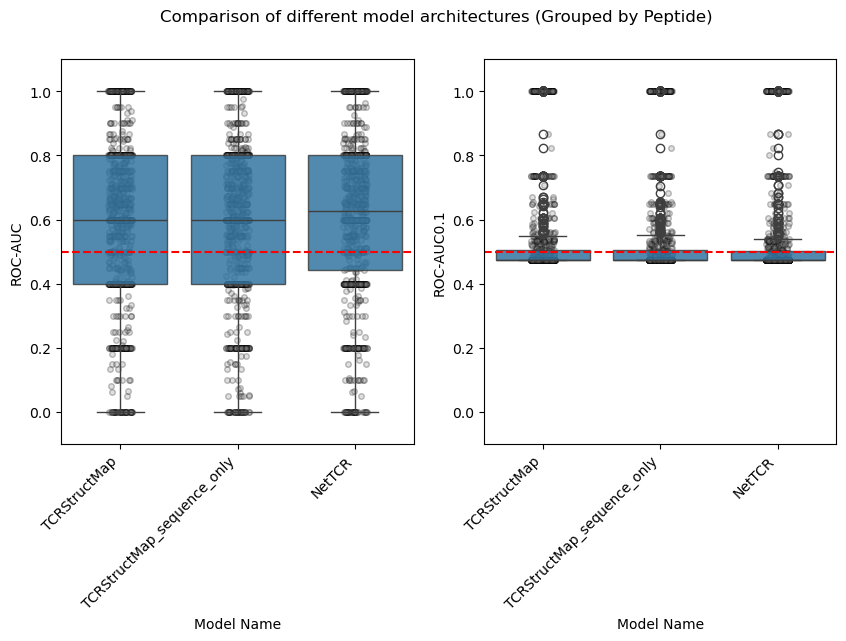

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

plt.suptitle('Comparison of different model architectures (Grouped by Peptide)')

for i, metric_name in enumerate(('roc_auc', 'roc_auc_01')):
    sns.stripplot(
        roc_results_by_peptide,
        x='model_name',
        y=metric_name,
        order=sorted(roc_results_by_peptide['model_name'].unique(), key=model_name_sort_key),
        color='grey',
        zorder=1,
        marker='o',
        size=4,
        edgecolor='black',
        linewidth=1,
        alpha=0.25,
        ax=axes[i],
    )

    sns.boxplot(
        roc_results_by_peptide,
        x='model_name',
        y=metric_name,
        order=sorted(roc_results_by_peptide['model_name'].unique(), key=model_name_sort_key),
        color='C0',
        boxprops={'alpha': 0.85},
        zorder=2,
        ax=axes[i],
    )

    axes[i].axhline(0.5, color='r', linestyle='dashed')

    axes[i].set_ylabel({'roc_auc': 'ROC-AUC', 'roc_auc_01': 'ROC-AUC0.1'}[metric_name])
    axes[i].set_xlabel('Model Name')

    axes[i].set_xticks(axes[i].get_xticks())
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')

    axes[i].set_ylim([-0.10, 1.1])

plt.show()

In [43]:
roc_results_by_peptide_agg = roc_results_by_peptide.groupby('model_name').agg(
    {'roc_auc': ['mean', 'median', 'std', 'count'], 'roc_auc_01': ['mean', 'median', 'std', 'count']}
)
roc_results_by_peptide_agg = roc_results_by_peptide_agg.loc[
    sorted(roc_results_by_peptide_agg.index, key=model_name_sort_key)
]
roc_results_by_peptide_agg.index.name = roc_results_by_peptide_agg.index.name.title().replace('_', ' ')

std_df = roc_results_by_peptide_agg.xs('std', axis=1, level=1)
count_df = roc_results_by_peptide_agg.xs('count', axis=1, level=1)

stderr_df = std_df / np.sqrt(count_df)
stderr_df.columns = pd.MultiIndex.from_product([stderr_df.columns, ['stderr']])

roc_results_by_peptide_agg = pd.concat([roc_results_by_peptide_agg, stderr_df], axis=1).sort_index(axis=1)
roc_results_by_peptide_agg = roc_results_by_peptide_agg.loc[
    :, roc_results_by_peptide_agg.columns.get_level_values(1) != 'count'
]

roc_results_by_peptide_agg_means = roc_results_by_peptide_agg.xs('mean', axis=1, level=1)
roc_results_by_peptide_agg_stderrs = roc_results_by_peptide_agg.xs('stderr', axis=1, level=1)

roc_results_by_peptide_agg = roc_results_by_peptide_agg_means.combine(
    roc_results_by_peptide_agg_stderrs, lambda mean, se: mean.map('{:.2f}'.format) + ' ± ' + se.map('{:.2e}'.format)
)

roc_results_by_peptide_agg = roc_results_by_peptide_agg[['roc_auc', 'roc_auc_01']].rename(
    lambda column_name: column_name.title().replace('_', ' ').replace('Roc Auc', 'ROC-AUC').replace('01', '0.1'),
    axis='columns',
)
roc_results_by_peptide_agg = roc_results_by_peptide_agg.rename({'TCRStructMap_sequence_only': f'{TAB}↳ Sequence Only'})

roc_results_by_peptide_agg_styler = roc_results_by_peptide_agg.style


def highlight_max(series: pd.Series, ref_vals: pd.Series) -> list[str]:
    is_max = series.index == ref_vals.idxmax()
    return ['font-weight: bold' if v else '' for v in is_max]


for col in roc_results_by_peptide_agg.columns:
    column_name = col.lower().replace(' ', '_').replace('-', '_').replace('.', '')
    roc_results_by_peptide_agg_styler = roc_results_by_peptide_agg_styler.apply(
        highlight_max, ref_vals=roc_results_by_peptide_agg_means[column_name], subset=[col]
    )

roc_results_by_peptide_agg_styler = roc_results_by_peptide_agg_styler.set_table_styles(
    [{'selector': '.row_heading', 'props': [('text-align', 'left')]}]
)

roc_results_by_peptide_agg_styler

,ROC-AUC,ROC-AUC 0.1
Model Name,,
TCRStructMap,0.60 ± 7.86e-03,0.55 ± 5.13e-03
↳ Sequence Only,0.61 ± 7.82e-03,0.55 ± 5.10e-03
NetTCR,0.62 ± 7.65e-03,0.55 ± 5.03e-03


In [44]:
for metric_name in ('roc_auc', 'roc_auc_01'):
    print({'roc_auc': 'ROC-AUC', 'roc_auc_01': 'ROC-AUC0.1'}[metric_name])
    ipy_display.display(pg.friedman(roc_results_by_peptide, dv=metric_name, within='model_name', subject='peptide'))

    groups = list(roc_results_by_peptide.set_index('peptide').groupby('model_name')[metric_name])
    groups = sorted(groups, key=lambda group: model_name_sort_key(group[0]))
    groups = [(group_name, group.sort_index()) for group_name, group in groups]

    significance_level = 0.05 / len(groups)

    results = collections.defaultdict(list)
    for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
        stat, p_val = stats.wilcoxon(group1, group2, alternative='greater')

        results['group1'].append(group1_name)
        results['group2'].append(group2_name)
        results['stat'].append(stat)
        results['p_val'].append(p_val)
        results['signficant'].append(p_val < significance_level)

    ipy_display.display(pd.DataFrame(results))
    print()

ROC-AUC


,Source,W,ddof1,Q,p-unc
Friedman,model_name,0.002141,2,4.424189,0.109471


,group1,group2,stat,p_val,signficant
0,TCRStructMap,TCRStructMap_sequence_only,152637.0,0.805217,False
1,TCRStructMap,NetTCR,163910.5,0.986103,False
2,TCRStructMap_sequence_only,NetTCR,165797.0,0.846038,False



ROC-AUC0.1


,Source,W,ddof1,Q,p-unc
Friedman,model_name,0.000695,2,1.435867,0.487759


,group1,group2,stat,p_val,signficant
0,TCRStructMap,TCRStructMap_sequence_only,35808.5,0.536846,False
1,TCRStructMap,NetTCR,42856.0,0.315492,False
2,TCRStructMap_sequence_only,NetTCR,38158.5,0.289944,False


In [45]:
model_groups = roc_results_by_peptide.groupby('model_name')

fpr_interp = np.linspace(0, 1, 100)
tpr_interp = {}

for model_name, model_group in model_groups:
    tpr_interp[model_name] = {}
    for fold, fold_group in model_group.groupby('peptide'):
        group = fold_group.explode(['tpr', 'fpr'])

        tpr_interp[model_name][fold] = np.interp(fpr_interp, group['fpr'].apply(float), group['tpr'].apply(float))

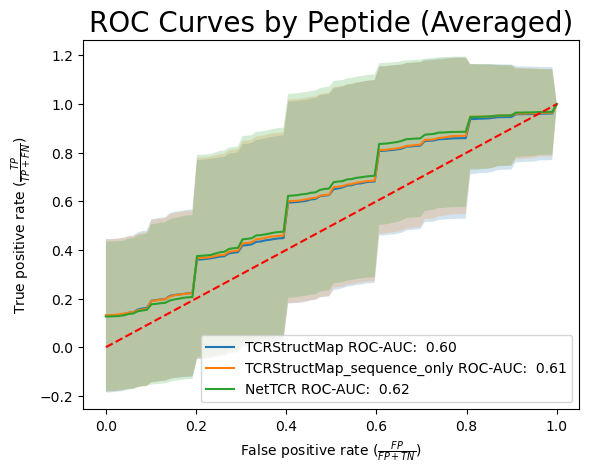

In [46]:
model_groups = roc_results_by_peptide.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

for model_name in model_group_names:
    model_group = model_groups.get_group(model_name)

    tpr_mean = np.mean(np.array(list(tpr_interp[model_name].values())).T, axis=1)
    tpr_std = np.std(np.array(list(tpr_interp[model_name].values())).T, axis=1)

    roc_auc = metrics.auc(fpr_interp, tpr_mean)

    plt.plot(fpr_interp, tpr_mean, label=f'{model_name} ROC-AUC: {roc_auc: .2f}')
    plt.fill_between(fpr_interp, tpr_mean - tpr_std, tpr_mean + tpr_std, alpha=0.2)

plt.title('ROC Curves by Peptide (Averaged)', fontsize=20)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel(r'False positive rate ($\frac{FP}{FP + TN}$)')
plt.ylabel(r'True positive rate ($\frac{TP}{TP + FN}$)')
plt.legend()

plt.show()

#### Comparison of prediction results to mimimum distance between the peptides and the training set

In [47]:
roc_results_by_peptide_by_peptide_distance = predictions.groupby(
    ['model_name', 'peptide', 'min_peptide_distance']
).apply(
    lambda group: metrics.roc_auc_score(group['label'], group['prediction']),
    include_groups=False,
)
roc_results_by_peptide_by_peptide_distance.name = 'roc_auc'

roc_results_by_peptide_by_peptide_distance = roc_results_by_peptide_by_peptide_distance.reset_index()

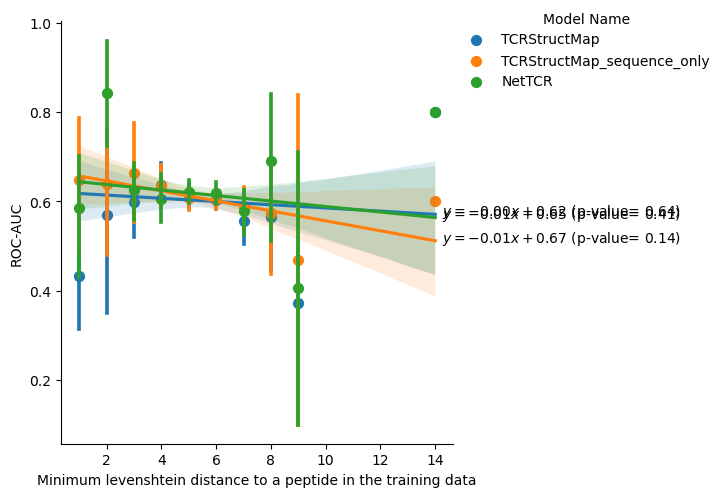

In [48]:
ax = sns.lmplot(
    roc_results_by_peptide_by_peptide_distance,
    x='min_peptide_distance',
    y='roc_auc',
    hue='model_name',
    hue_order=sorted(roc_results_by_peptide_by_peptide_distance['model_name'].unique(), key=model_name_sort_key),
    x_estimator=np.mean,
)

for model_name in roc_results_by_peptide_by_peptide_distance['model_name'].unique():
    subset = roc_results_by_peptide_by_peptide_distance[
        roc_results_by_peptide_by_peptide_distance['model_name'] == model_name
    ]
    slope, intercept, r_value, p_value, std_err = stats.linregress(subset['min_peptide_distance'], subset['roc_auc'])

    equation = f'$y = {slope:.2f}x + {intercept:.2f}$ (p-value={p_value: .2f})'

    x_pos = subset['min_peptide_distance'].max() + 0.25
    y_pos = slope * x_pos + intercept

    plt.text(x_pos, y_pos, equation, color='black')

ax.legend.set_title('Model Name')
ax.legend.set_loc('upper right')

plt.xlabel('Minimum levenshtein distance to a peptide in the training data')
plt.ylabel('ROC-AUC')

plt.show()

## Precision-Recall

In [49]:
pr_results = predictions.groupby(['model_name']).apply(
    lambda group: metrics.precision_recall_curve(group['label'], group['prediction']),
    include_groups=False,
)
pr_results.name = 'pr_curve'
pr_results = pr_results.reset_index()

In [50]:
pr_results[['precision', 'recall', 'threshold']] = pr_results['pr_curve'].apply(pd.Series)

In [51]:
pr_results['pr_auc'] = pr_results.apply(lambda row: metrics.auc(row['recall'], row['precision']), axis=1)

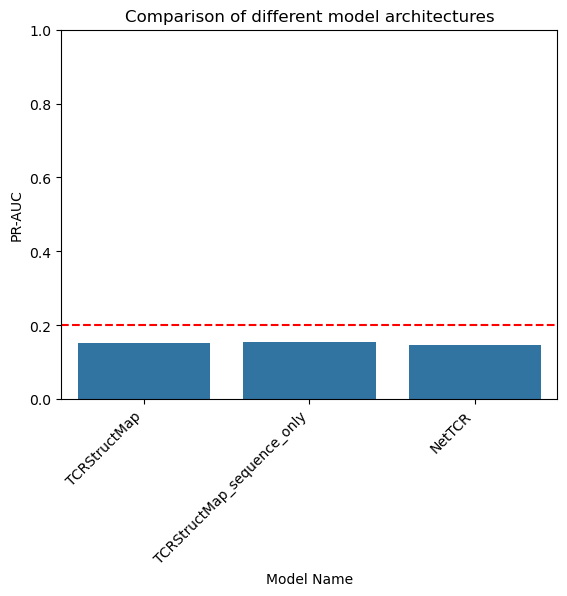

In [52]:
sns.barplot(pr_results, x='model_name', y='pr_auc', order=sorted(pr_results['model_name'], key=model_name_sort_key))
plt.axhline(1 / 5, color='r', linestyle='dashed')

plt.title('Comparison of different model architectures')
plt.ylim([0.0, 1.0])
plt.xlabel('Model Name')
plt.ylabel('PR-AUC')
plt.xticks(rotation=45, ha='right')
plt.show()

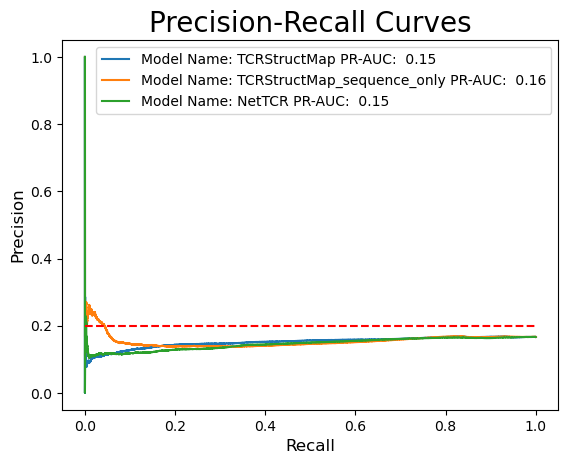

In [53]:
model_groups = pr_results.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=lambda name: (-ord(name[0]), name, len(name)))

plt.title('Precision-Recall Curves', fontsize=20)

for model_name in model_group_names:
    model_group = model_groups.get_group(model_name)

    pr_auc = model_group['pr_auc'].to_numpy()[0]
    group = model_group.explode(['precision', 'recall'])

    plt.plot(group['recall'], group['precision'], label=f'Model Name: {model_name} PR-AUC: {pr_auc: .2f}')

plt.ylabel('Precision', fontsize=12)
plt.xlabel('Recall', fontsize=12)

plt.plot([0, 1], [1 / 5, 1 / 5], 'r--')
plt.legend()

plt.show()

In [54]:
pr_results_agg = pr_results[['model_name', 'pr_auc']]
pr_results_agg = pr_results_agg.sort_values('model_name', key=lambda col: col.map(model_name_sort_key))
pr_results_agg = pr_results_agg.rename(
    lambda column_name: (
        column_name.title()
        .replace('_', ' ')
        .replace('Roc Auc', 'ROC-AUC')
        .replace('Pr Auc', 'PR-AUC')
        .replace('01', '0.1')
    ),
    axis='columns',
)
pr_results_agg = pr_results_agg.replace('TCRStructMap_sequence_only', f'{TAB}↳ Sequence Only')
pr_results_agg = pr_results_agg.set_index('Model Name')

pr_results_agg_styler = pr_results_agg.style
pr_results_agg_styler = pr_results_agg_styler.format(precision=2)
pr_results_agg_styler = pr_results_agg_styler.highlight_max(axis=0, props='font-weight: bold;')
pr_results_agg_styler = pr_results_agg_styler.set_table_styles(
    [{'selector': '.row_heading', 'props': [('text-align', 'left')]}]
)

pr_results_agg_styler

,PR-AUC
Model Name,
TCRStructMap,0.15
↳ Sequence Only,0.16
NetTCR,0.15


### Grouping PR-AUC by Fold

In [55]:
pr_results_by_fold = predictions.groupby(['model_name', 'fold']).apply(
    lambda group: metrics.precision_recall_curve(group['label'], group['prediction']),
    include_groups=False,
)
pr_results_by_fold.name = 'pr_curve'
pr_results_by_fold = pr_results_by_fold.reset_index()

In [56]:
pr_results_by_fold[['precision', 'recall', 'threshold']] = pr_results_by_fold['pr_curve'].apply(pd.Series)

In [57]:
pr_results_by_fold['pr_auc'] = pr_results_by_fold.apply(
    lambda row: metrics.auc(row['recall'], row['precision']), axis=1
)

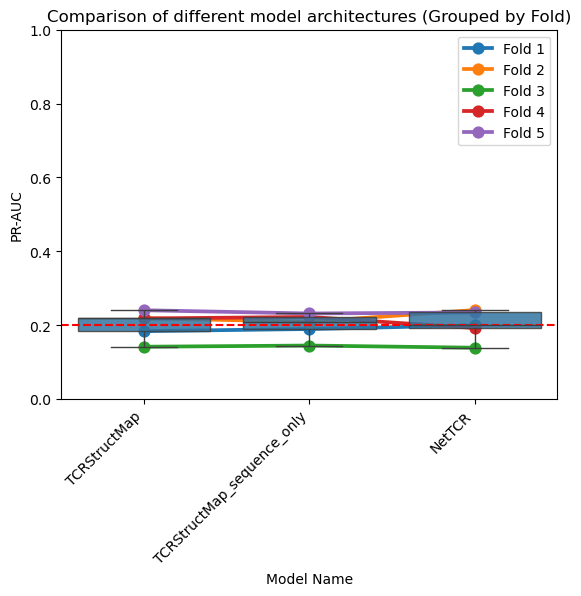

In [58]:
ax = sns.pointplot(
    pr_results_by_fold,
    x='model_name',
    y='pr_auc',
    order=sorted(pr_results_by_fold['model_name'], key=model_name_sort_key),
    hue='fold',
)

sns.boxplot(
    pr_results_by_fold,
    x='model_name',
    y='pr_auc',
    order=sorted(pr_results_by_fold['model_name'], key=model_name_sort_key),
    color='C0',
    boxprops={'alpha': 0.85},
)
plt.axhline(0.2, color='r', linestyle='dashed')

plt.title('Comparison of different model architectures (Grouped by Fold)')
plt.ylim([0.0, 1.0])
plt.xlabel('Model Name')
plt.ylabel('PR-AUC')
plt.xticks(rotation=45, ha='right')

handles, labels = ax.get_legend_handles_labels()
new_labels = [f'Fold {label}' for label in labels]
ax.legend(handles, new_labels)

plt.show()

In [59]:
pr_results_by_fold_agg = pr_results_by_fold.groupby('model_name').agg({'pr_auc': ['mean', 'median', 'std', 'count']})
pr_results_by_fold_agg = pr_results_by_fold_agg.loc[sorted(pr_results_by_fold_agg.index, key=model_name_sort_key)]

pr_results_by_fold_agg = pr_results_by_fold_agg.loc[sorted(pr_results_by_fold_agg.index, key=model_name_sort_key)]
pr_results_by_fold_agg.index.name = pr_results_by_fold_agg.index.name.title().replace('_', ' ')

std_df = pr_results_by_fold_agg.xs('std', axis=1, level=1)
count_df = pr_results_by_fold_agg.xs('count', axis=1, level=1)

stderr_df = std_df / np.sqrt(count_df)
stderr_df.columns = pd.MultiIndex.from_product([stderr_df.columns, ['stderr']])

pr_results_by_fold_agg = pd.concat([pr_results_by_fold_agg, stderr_df], axis=1).sort_index(axis=1)
pr_results_by_fold_agg = pr_results_by_fold_agg.loc[:, pr_results_by_fold_agg.columns.get_level_values(1) != 'count']

pr_results_by_fold_agg_means = pr_results_by_fold_agg.xs('mean', axis=1, level=1)
pr_results_by_fold_agg_stderrs = pr_results_by_fold_agg.xs('stderr', axis=1, level=1)

pr_results_by_fold_agg = pr_results_by_fold_agg_means.combine(
    pr_results_by_fold_agg_stderrs, lambda mean, se: mean.map('{:.2f}'.format) + ' ± ' + se.map('{:.2e}'.format)
)

pr_results_by_fold_agg = (
    pr_results_by_fold_agg[['pr_auc']]
    .rename(
        lambda column_name: (
            column_name.title()
            .replace('_', ' ')
            .replace('Roc Auc', 'ROC-AUC')
            .replace('Pr Auc', 'PR-AUC')
            .replace('01', '0.1')
        ),
        axis='columns',
    )
    .replace('TCRStructMap_sequence_only', 'TCRStructMap (Sequence Only)')
)
pr_results_by_fold_agg = pr_results_by_fold_agg.rename({'TCRStructMap_sequence_only': f'{TAB}↳ Sequence Only'})

pr_results_by_fold_agg_styler = pr_results_by_fold_agg.style


def highlight_max(series: pd.Series, ref_vals: pd.Series) -> list[str]:
    is_max = series.index == ref_vals.idxmax()
    return ['font-weight: bold' if v else '' for v in is_max]


for col in pr_results_by_fold_agg.columns:
    column_name = col.lower().replace(' ', '_').replace('-', '_').replace('.', '')
    pr_results_by_fold_agg_styler = pr_results_by_fold_agg_styler.apply(
        highlight_max, ref_vals=pr_results_by_fold_agg_means[column_name], subset=[col]
    )

pr_results_by_fold_agg_styler = pr_results_by_fold_agg_styler.set_table_styles(
    [{'selector': '.row_heading', 'props': [('text-align', 'left')]}]
)

pr_results_by_fold_agg_styler

,PR-AUC
Model Name,
TCRStructMap,0.20 ± 1.73e-02
↳ Sequence Only,0.20 ± 1.54e-02
NetTCR,0.20 ± 1.82e-02


In [60]:
pg.friedman(pr_results_by_fold, dv='pr_auc', within='model_name', subject='fold', method='f')

,Source,W,ddof1,ddof2,F,p-unc
Friedman,model_name,0.0,1.6,6.4,0.0,1.0


In [61]:
groups = list(pr_results_by_fold.set_index('fold').groupby('model_name')['pr_auc'])
groups = sorted(groups, key=lambda group: model_name_sort_key(group[0]))
groups = [(group_name, group.sort_index()) for group_name, group in groups]

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.wilcoxon(group1, group2, alternative='greater')

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

,group1,group2,stat,p_val,signficant
0,TCRStructMap,TCRStructMap_sequence_only,9.0,0.40625,False
1,TCRStructMap,NetTCR,8.0,0.50000,False
2,TCRStructMap_sequence_only,NetTCR,6.0,0.68750,False


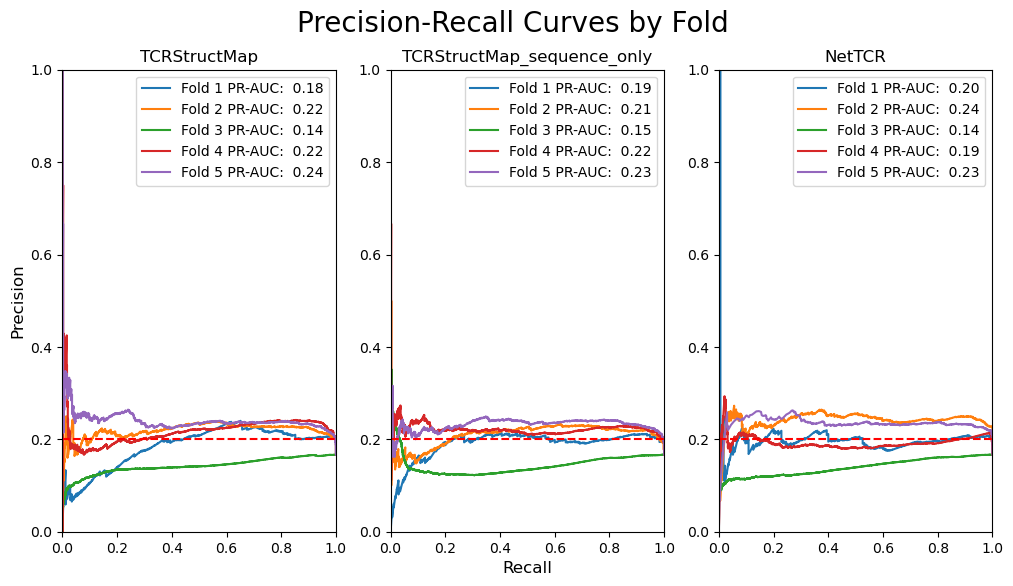

In [62]:
model_groups = pr_results_by_fold.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('Precision-Recall Curves by Fold', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        pr_auc = fold_group['pr_auc'].to_numpy()[0]
        group = fold_group.explode(['recall', 'precision'])

        axes[i].plot(group['recall'], group['precision'], label=f'Fold {fold} PR-AUC: {pr_auc: .2f}')

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [1 / 5, 1 / 5], 'r--')

    if i == 0:
        axes[i].set_ylabel('Precision', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel('Recall', fontsize=12)

    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1])
    axes[i].legend()

In [63]:
model_groups = pr_results_by_fold.groupby('model_name')

recall_interp = np.linspace(0, 1, 100)
precision_interp = {}

for model_name, model_group in model_groups:
    precision_interp[model_name] = {}
    for fold, fold_group in model_group.groupby('fold'):
        group = fold_group.explode(['recall', 'precision'])

        precision_interp[model_name][fold] = np.interp(
            recall_interp,
            group['recall'].apply(float)[::-1],
            group['precision'].apply(float)[::-1],
        )

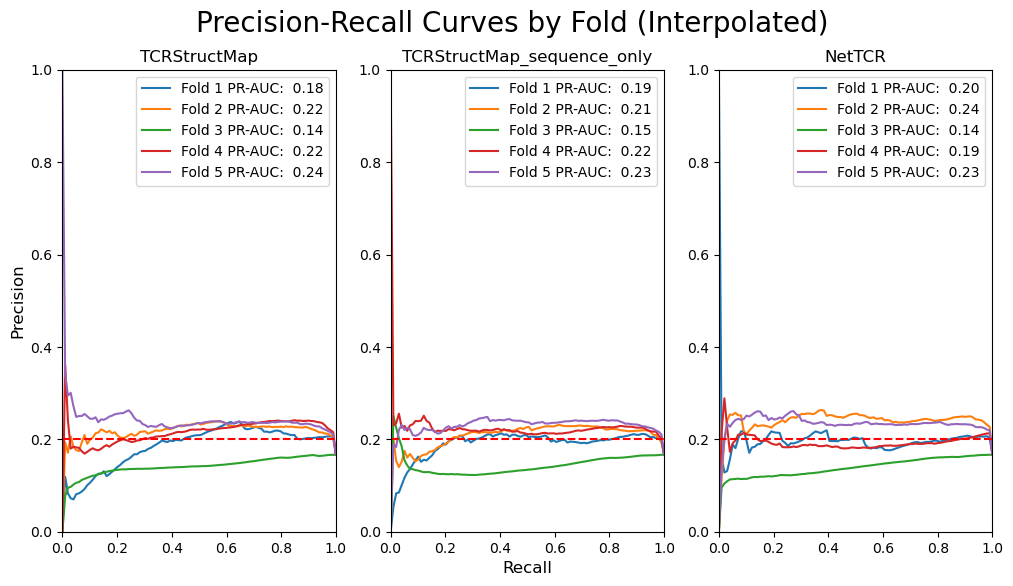

In [64]:
model_groups = pr_results_by_fold.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('Precision-Recall Curves by Fold (Interpolated)', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        pr_auc = fold_group['pr_auc'].to_numpy()[0]

        axes[i].plot(recall_interp, precision_interp[model_name][fold], label=f'Fold {fold} PR-AUC: {pr_auc: .2f}')

    if i == 0:
        axes[i].set_ylabel('Precision', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel('Recall', fontsize=12)

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [1 / 5, 1 / 5], 'r--')
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1])
    axes[i].legend()

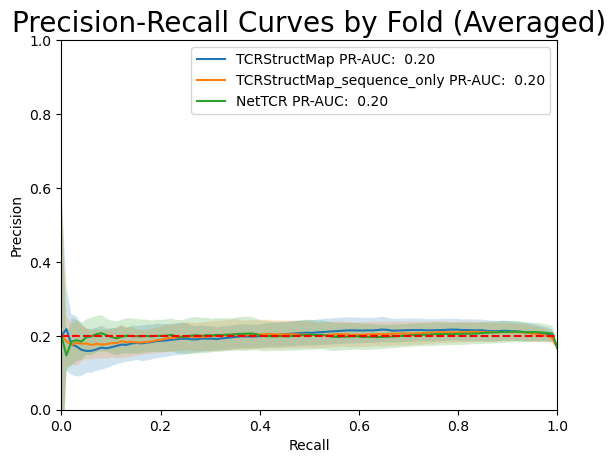

In [65]:
model_groups = pr_results_by_fold.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

for model_name in model_group_names:
    precision_mean = np.mean(np.array(list(precision_interp[model_name].values())).T, axis=1)
    precision_std = np.std(np.array(list(precision_interp[model_name].values())).T, axis=1)

    pr_auc = metrics.auc(recall_interp, precision_mean)

    plt.plot(recall_interp, precision_mean, label=f'{model_name} PR-AUC: {pr_auc: .2f}')
    plt.fill_between(recall_interp, precision_mean - precision_std, precision_mean + precision_std, alpha=0.2)

plt.title('Precision-Recall Curves by Fold (Averaged)', fontsize=20)
plt.plot([0, 1], [1 / 5, 1 / 5], 'r--')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.legend()

plt.show()

### Balancing classes

In [66]:
def down_sample_group(group: pd.DataFrame, random_state: int | np.random.Generator | None = None) -> pd.DataFrame:
    positives = group[group['label'] == 1]
    negatives = group[group['label'] == 0]

    num_positives = len(positives)
    num_negatives = len(negatives)

    if num_positives > num_negatives:
        return pd.concat([positives.sample(num_negatives, random_state=random_state), negatives])

    if num_positives < num_negatives:
        return pd.concat([positives, negatives.sample(num_positives, random_state=random_state)])

    return group


rng = np.random.default_rng(123)
balanced_predictions = (
    predictions.groupby(['model_name', 'fold'])
    .apply(
        down_sample_group,
        random_state=rng,
        include_groups=False,
    )
    .reset_index()
)

In [67]:
pr_results_by_fold_balanced = balanced_predictions.groupby(['model_name', 'fold']).apply(
    lambda group: metrics.precision_recall_curve(group['label'], group['prediction']),
    include_groups=False,
)
pr_results_by_fold_balanced.name = 'pr_curve'
pr_results_by_fold_balanced = pr_results_by_fold_balanced.reset_index()

In [68]:
pr_results_by_fold_balanced[['precision', 'recall', 'threshold']] = pr_results_by_fold_balanced['pr_curve'].apply(
    pd.Series
)

In [69]:
pr_results_by_fold_balanced['pr_auc'] = pr_results_by_fold_balanced.apply(
    lambda row: metrics.auc(row['recall'], row['precision']), axis=1
)

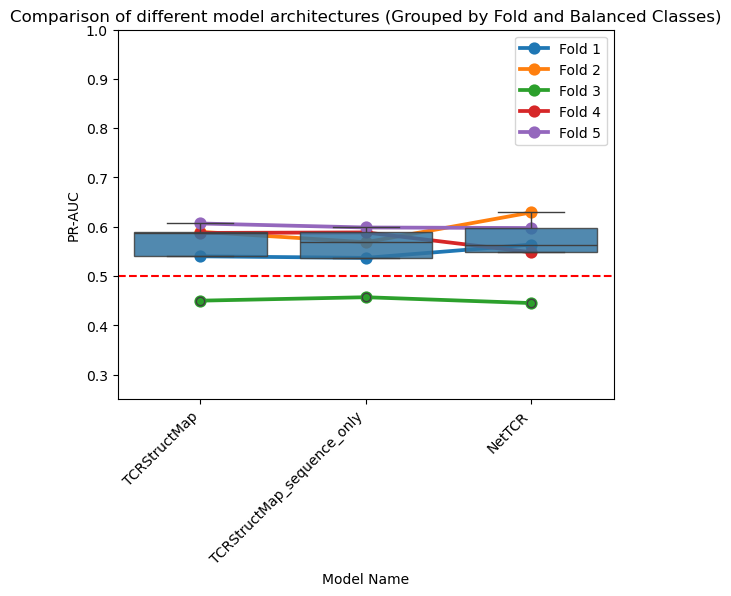

In [70]:
ax = sns.pointplot(
    pr_results_by_fold_balanced,
    x='model_name',
    y='pr_auc',
    order=sorted(pr_results_by_fold_balanced['model_name'].unique(), key=model_name_sort_key),
    hue='fold',
)

sns.boxplot(
    pr_results_by_fold_balanced,
    x='model_name',
    y='pr_auc',
    order=sorted(pr_results_by_fold_balanced['model_name'].unique(), key=model_name_sort_key),
    color='C0',
    boxprops={'alpha': 0.85},
)

plt.axhline(0.5, color='r', linestyle='dashed')

plt.title('Comparison of different model architectures (Grouped by Fold and Balanced Classes)')
plt.xlabel('Model Name')
plt.ylabel('PR-AUC')
plt.xticks(rotation=45, ha='right')
plt.ylim([0.25, 1.0])

handles, labels = ax.get_legend_handles_labels()
new_labels = [f'Fold {label}' for label in labels]
ax.legend(handles, new_labels)

plt.show()

In [71]:
pr_results_by_fold_balanced_agg = pr_results_by_fold_balanced.groupby('model_name').agg(
    {'pr_auc': ['mean', 'median', 'std', 'count']}
)
pr_results_by_fold_balanced_agg = pr_results_by_fold_balanced_agg.loc[
    sorted(pr_results_by_fold_balanced_agg.index, key=model_name_sort_key)
]

pr_results_by_fold_balanced_agg = pr_results_by_fold_balanced_agg.loc[
    sorted(pr_results_by_fold_balanced_agg.index, key=model_name_sort_key)
]
pr_results_by_fold_balanced_agg.index.name = pr_results_by_fold_balanced_agg.index.name.title().replace('_', ' ')

std_df = pr_results_by_fold_balanced_agg.xs('std', axis=1, level=1)
count_df = pr_results_by_fold_balanced_agg.xs('count', axis=1, level=1)

stderr_df = std_df / np.sqrt(count_df)
stderr_df.columns = pd.MultiIndex.from_product([stderr_df.columns, ['stderr']])

pr_results_by_fold_balanced_agg = pd.concat([pr_results_by_fold_balanced_agg, stderr_df], axis=1).sort_index(axis=1)
pr_results_by_fold_balanced_agg = pr_results_by_fold_balanced_agg.loc[
    :, pr_results_by_fold_balanced_agg.columns.get_level_values(1) != 'count'
]

means = pr_results_by_fold_balanced_agg.xs('mean', axis=1, level=1)
stderrs = pr_results_by_fold_balanced_agg.xs('stderr', axis=1, level=1)

pr_results_by_fold_balanced_agg = means.combine(
    stderrs, lambda mean, se: mean.map('{:.2f}'.format) + ' ± ' + se.map('{:.2e}'.format)
)

pr_results_by_fold_balanced_agg = pr_results_by_fold_balanced_agg[['pr_auc']].rename(
    lambda column_name: (
        column_name.title()
        .replace('_', ' ')
        .replace('Roc Auc', 'ROC-AUC')
        .replace('Pr Auc', 'PR-AUC')
        .replace('01', '0.1')
    ),
    axis='columns',
)
pr_results_by_fold_balanced_agg = pr_results_by_fold_balanced_agg.rename(
    {'TCRStructMap_sequence_only': 'TCRStructMap (Sequence Only)'}
)

pr_results_by_fold_balanced_agg_styler = pr_results_by_fold_balanced_agg.style


def highlight_max(series: pd.Series, ref_vals: pd.Series) -> list[str]:
    is_max = series.index == ref_vals.idxmax()
    return ['font-weight: bold' if v else '' for v in is_max]


for col in pr_results_by_fold_balanced_agg.columns:
    column_name = col.lower().replace(' ', '_').replace('-', '_').replace('.', '')
    pr_results_by_fold_balanced_agg_styler = pr_results_by_fold_balanced_agg_styler.apply(
        highlight_max, ref_vals=means[column_name], subset=[col]
    )

pr_results_by_fold_balanced_agg_styler

,PR-AUC
Model Name,
TCRStructMap,0.55 ± 2.84e-02
TCRStructMap (Sequence Only),0.55 ± 2.55e-02
NetTCR,0.56 ± 3.12e-02


In [72]:
pg.friedman(pr_results_by_fold_balanced, dv='pr_auc', within='model_name', subject='fold', method='f')

,Source,W,ddof1,ddof2,F,p-unc
Friedman,model_name,0.04,1.6,6.4,0.166667,0.805424


In [73]:
groups = list(pr_results_by_fold_balanced.set_index('fold').groupby('model_name')['pr_auc'])
groups = sorted(groups, key=lambda group: model_name_sort_key(group[0]))
groups = [(group_name, group.sort_index()) for group_name, group in groups]


significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.wilcoxon(group1, group2, alternative='greater')

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

,group1,group2,stat,p_val,signficant
0,TCRStructMap,TCRStructMap_sequence_only,11.0,0.21875,False
1,TCRStructMap,NetTCR,7.0,0.59375,False
2,TCRStructMap_sequence_only,NetTCR,7.0,0.59375,False


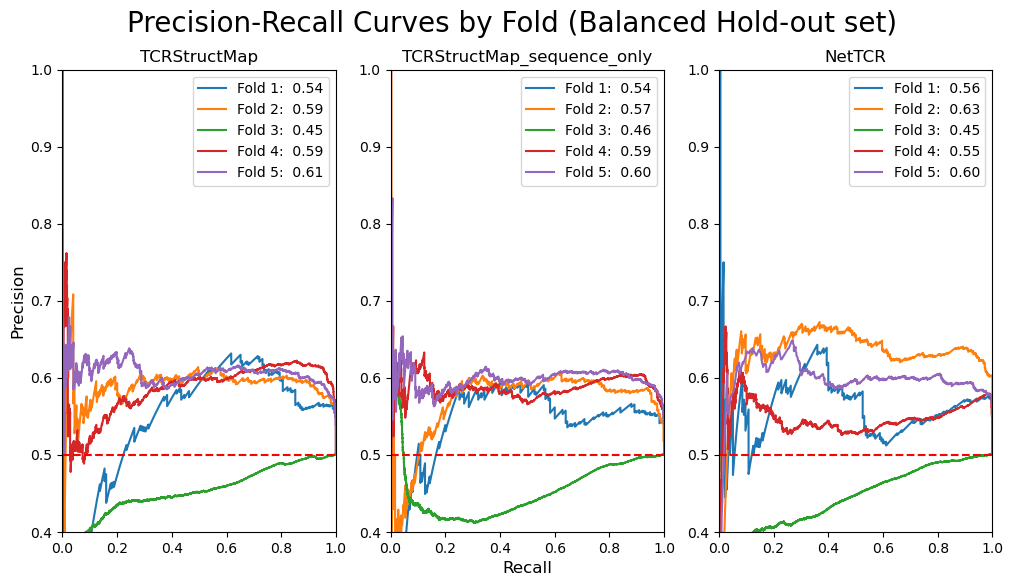

In [74]:
model_groups = pr_results_by_fold_balanced.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('Precision-Recall Curves by Fold (Balanced Hold-out set)', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        roc_auc = fold_group['pr_auc'].to_numpy()[0]
        group = fold_group.explode(['recall', 'precision'])

        axes[i].plot(group['recall'], group['precision'], label=f'Fold {fold}: {roc_auc: .2f}')

    if i == 0:
        axes[i].set_ylabel('Precision', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel('Recall', fontsize=12)

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [0.5, 0.5], 'r--')
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0.4, 1])
    axes[i].legend()

In [75]:
model_groups = pr_results_by_fold_balanced.groupby('model_name')

recall_interp = np.linspace(0, 1, 100)
precision_interp = {}

for model_name, model_group in model_groups:
    precision_interp[model_name] = {}
    for fold, fold_group in model_group.groupby('fold'):
        group = fold_group.explode(['recall', 'precision'])

        precision_interp[model_name][fold] = np.interp(
            recall_interp,
            group['recall'].apply(float)[::-1],
            group['precision'].apply(float)[::-1],
        )

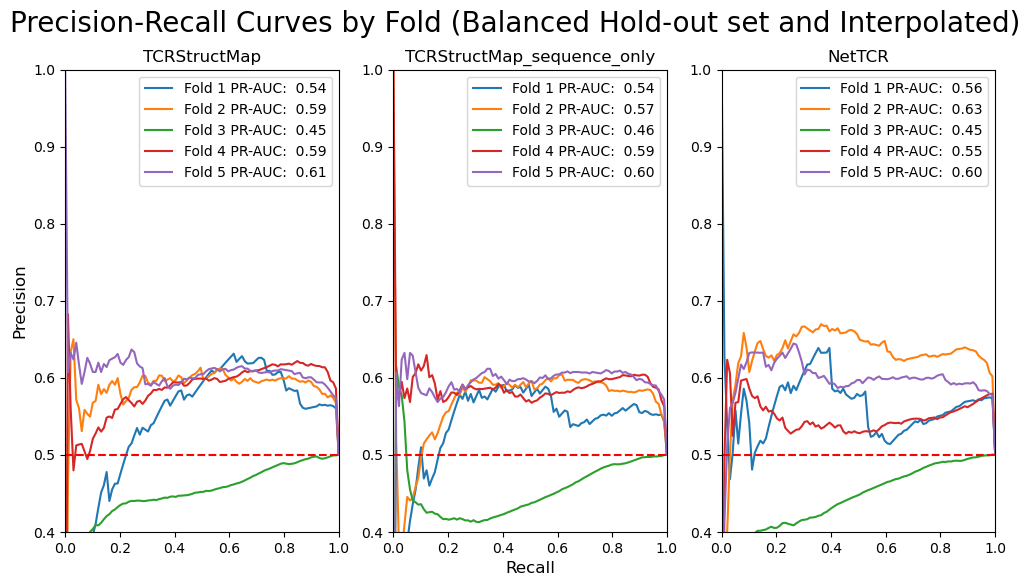

In [76]:
model_groups = pr_results_by_fold_balanced.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('Precision-Recall Curves by Fold (Balanced Hold-out set and Interpolated)', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        pr_auc = fold_group['pr_auc'].to_numpy()[0]

        axes[i].plot(recall_interp, precision_interp[model_name][fold], label=f'Fold {fold} PR-AUC: {pr_auc: .2f}')

    if i == 0:
        axes[i].set_ylabel('Precision', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel('Recall', fontsize=12)

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [0.5, 0.5], 'r--')
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0.4, 1])
    axes[i].legend()

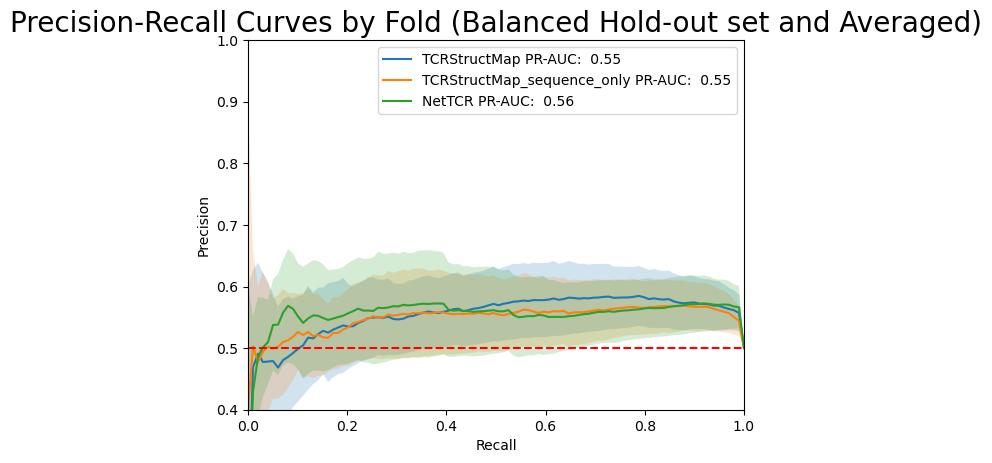

In [77]:
model_groups = pr_results_by_fold_balanced.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

for model_name in model_group_names:
    precision_mean = np.mean(np.array(list(precision_interp[model_name].values())).T, axis=1)
    precision_std = np.std(np.array(list(precision_interp[model_name].values())).T, axis=1)

    pr_auc = metrics.auc(recall_interp, precision_mean)

    plt.plot(recall_interp, precision_mean, label=f'{model_name} PR-AUC: {pr_auc: .2f}')
    plt.fill_between(recall_interp, precision_mean - precision_std, precision_mean + precision_std, alpha=0.2)

plt.title('Precision-Recall Curves by Fold (Balanced Hold-out set and Averaged)', fontsize=20)
plt.plot([0, 1], [0.5, 0.5], 'r--')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.xlim([0, 1])
plt.ylim([0.4, 1])
plt.legend()

plt.show()

## F1-Score

In [78]:
THRESHOLD = 0.5
predictions['prediction_binary'] = (predictions['prediction'] > THRESHOLD).apply(int)

In [79]:
f1_results = predictions.groupby(['model_name']).apply(
    lambda row: metrics.f1_score(row['label'], row['prediction_binary']),
    include_groups=False,
)
f1_results.name = 'f1_score'
f1_results = f1_results.reset_index()

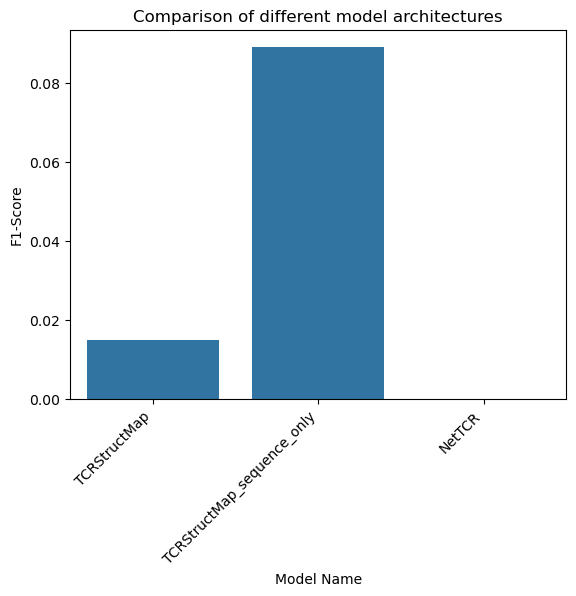

In [80]:
sns.barplot(
    f1_results,
    x='model_name',
    y='f1_score',
    order=sorted(f1_results['model_name'].unique(), key=model_name_sort_key),
)

plt.title('Comparison of different model architectures')
plt.xlabel('Model Name')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.show()

In [81]:
f1_results_agg = f1_results[['model_name', 'f1_score']]

f1_results_agg = f1_results_agg.sort_values('model_name', key=lambda col: col.map(model_name_sort_key))

f1_results_agg = f1_results_agg.rename(
    lambda column_name: column_name.title().replace('_', ' ').replace('F1 Score', 'F1-Score').replace('01', '0.1'),
    axis='columns',
)

f1_results_agg = f1_results_agg.replace('TCRStructMap_sequence_only', f'{TAB}↳ Sequence Only')

f1_results_agg = f1_results_agg.set_index('Model Name')

f1_results_agg_styler = f1_results_agg.style
f1_results_agg_styler = f1_results_agg_styler.set_table_styles(
    [{'selector': '.row_heading', 'props': [('text-align', 'left')]}]
)
f1_results_agg_styler = f1_results_agg_styler.format(precision=2)
f1_results_agg_styler = f1_results_agg_styler.highlight_max(axis=0, props='font-weight: bold;')

f1_results_agg_styler

,F1-Score
Model Name,
TCRStructMap,0.02
↳ Sequence Only,0.09
NetTCR,0.00


### Grouping F1-Score by Fold

In [82]:
f1_results_by_fold = predictions.groupby(['model_name', 'fold']).apply(
    lambda row: metrics.f1_score(row['label'], row['prediction_binary']),
    include_groups=False,
)
f1_results_by_fold.name = 'f1_score'
f1_results_by_fold = f1_results_by_fold.reset_index()

f1_results_table = f1_results_by_fold.pivot_table(index='fold', columns='model_name', values='f1_score')
f1_results_table = f1_results_table[sorted(f1_results_table.columns, key=model_name_sort_key)]
f1_results_table

model_name,TCRStructMap,TCRStructMap_sequence_only,NetTCR
fold,,,
1,0.000000,0.019048,0.0
2,0.030501,0.047337,0.0
3,0.011831,0.080681,0.0
4,0.051738,0.184382,0.0
5,0.002608,0.080087,0.0


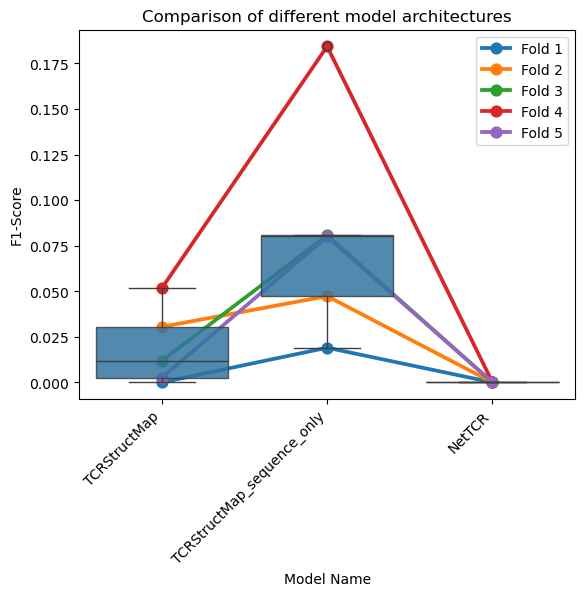

In [83]:
ax = sns.pointplot(
    f1_results_by_fold,
    x='model_name',
    y='f1_score',
    order=sorted(f1_results_by_fold['model_name'].unique(), key=model_name_sort_key),
    hue='fold',
)

sns.boxplot(
    f1_results_by_fold,
    x='model_name',
    y='f1_score',
    order=sorted(f1_results_by_fold['model_name'].unique(), key=model_name_sort_key),
    color='C0',
    boxprops={'alpha': 0.85},
)

plt.title('Comparison of different model architectures')
plt.xlabel('Model Name')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')

handles, labels = ax.get_legend_handles_labels()
new_labels = [f'Fold {label}' for label in labels]
ax.legend(handles, new_labels)

plt.show()

In [84]:
f1_results_by_fold_agg = f1_results_by_fold.groupby('model_name').agg({'f1_score': ['mean', 'median', 'std', 'count']})

f1_results_by_fold_agg = f1_results_by_fold_agg.loc[sorted(f1_results_by_fold_agg.index, key=model_name_sort_key)]
f1_results_by_fold_agg.index.name = f1_results_by_fold_agg.index.name.title().replace('_', ' ')

std_df = f1_results_by_fold_agg.xs('std', axis=1, level=1)
count_df = f1_results_by_fold_agg.xs('count', axis=1, level=1)

stderr_df = std_df / np.sqrt(count_df)
stderr_df.columns = pd.MultiIndex.from_product([stderr_df.columns, ['stderr']])

f1_results_by_fold_agg = pd.concat([f1_results_by_fold_agg, stderr_df], axis=1).sort_index(axis=1)
f1_results_by_fold_agg = f1_results_by_fold_agg.loc[:, f1_results_by_fold_agg.columns.get_level_values(1) != 'count']

f1_results_by_fold_agg_means = f1_results_by_fold_agg.xs('mean', axis=1, level=1)
f1_results_by_fold_agg_stderrs = f1_results_by_fold_agg.xs('stderr', axis=1, level=1)

f1_results_by_fold_agg = f1_results_by_fold_agg_means.combine(
    f1_results_by_fold_agg_stderrs, lambda mean, se: mean.map('{:.2f}'.format) + ' ± ' + se.map('{:.2e}'.format)
)

f1_results_by_fold_agg = f1_results_by_fold_agg[['f1_score']].rename(
    lambda column_name: (
        column_name.title()
        .replace('_', ' ')
        .replace('Roc Auc', 'ROC-AUC')
        .replace('Pr Auc', 'PR-AUC')
        .replace('F1 Score', 'F1-Score')
        .replace('01', '0.1')
    ),
    axis='columns',
)
f1_results_by_fold_agg = f1_results_by_fold_agg.rename({'TCRStructMap_sequence_only': f'{TAB}↳ Sequence Only'})

f1_results_by_fold_agg_styler = f1_results_by_fold_agg.style


def highlight_max(series: pd.Series, ref_vals: pd.Series) -> list[str]:
    is_max = series.index == ref_vals.idxmax()
    return ['font-weight: bold' if v else '' for v in is_max]


for col in f1_results_by_fold_agg.columns:
    column_name = col.lower().replace(' ', '_').replace('-', '_').replace('.', '')
    f1_results_by_fold_agg_styler = f1_results_by_fold_agg_styler.apply(
        highlight_max, ref_vals=f1_results_by_fold_agg_means[column_name], subset=[col]
    )

f1_results_by_fold_agg_styler = f1_results_by_fold_agg_styler.set_table_styles(
    [{'selector': '.row_heading', 'props': [('text-align', 'left')]}]
)

f1_results_by_fold_agg_styler

,F1-Score
Model Name,
TCRStructMap,0.02 ± 9.71e-03
↳ Sequence Only,0.08 ± 2.80e-02
NetTCR,0.00 ± 0.00e+00


In [85]:
pg.friedman(f1_results_by_fold, dv='f1_score', within='model_name', subject='fold', method='f')

,Source,W,ddof1,ddof2,F,p-unc
Friedman,model_name,0.957895,1.6,6.4,91.0,0.000026


In [86]:
groups = list(f1_results_by_fold.set_index('fold').groupby('model_name')['f1_score'])
groups = sorted(groups, key=lambda group: model_name_sort_key(group[0]))
groups = [(group_name, group.sort_index()) for group_name, group in groups]

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.wilcoxon(group1, group2, alternative='greater')

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

,group1,group2,stat,p_val,signficant
0,TCRStructMap,TCRStructMap_sequence_only,0.0,1.00000,False
1,TCRStructMap,NetTCR,10.0,0.06250,False
2,TCRStructMap_sequence_only,NetTCR,15.0,0.03125,False


### Balancing classes

In [87]:
balanced_predictions['prediction_binary'] = (balanced_predictions['prediction'] > THRESHOLD).apply(int)

In [88]:
f1_results_by_fold_balanced = balanced_predictions.groupby(['model_name', 'fold']).apply(
    lambda row: metrics.f1_score(row['label'], row['prediction_binary']),
    include_groups=False,
)
f1_results_by_fold_balanced.name = 'f1_score'
f1_results_by_fold_balanced = f1_results_by_fold_balanced.reset_index()

f1_results_balanced_table = f1_results_by_fold_balanced.pivot_table(
    index='fold', columns='model_name', values='f1_score'
)
f1_results_balanced_table = f1_results_balanced_table[
    sorted(f1_results_balanced_table.columns, key=model_name_sort_key)
]
f1_results_balanced_table

model_name,TCRStructMap,TCRStructMap_sequence_only,NetTCR
fold,,,
1,0.000000,0.021622,0.0
2,0.031746,0.052174,0.0
3,0.012568,0.099256,0.0
4,0.056637,0.250000,0.0
5,0.002608,0.089697,0.0


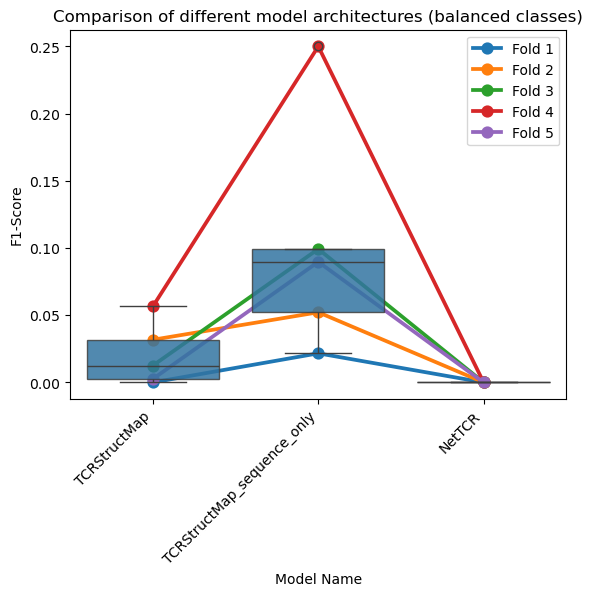

In [89]:
ax = sns.pointplot(
    f1_results_by_fold_balanced,
    x='model_name',
    y='f1_score',
    order=sorted(f1_results_by_fold_balanced['model_name'].unique(), key=model_name_sort_key),
    hue='fold',
)

sns.boxplot(
    f1_results_by_fold_balanced,
    x='model_name',
    y='f1_score',
    order=sorted(f1_results_by_fold_balanced['model_name'].unique(), key=model_name_sort_key),
    color='C0',
    boxprops={'alpha': 0.85},
)

plt.title('Comparison of different model architectures (balanced classes)')
plt.xlabel('Model Name')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')

handles, labels = ax.get_legend_handles_labels()
new_labels = [f'Fold {label}' for label in labels]
ax.legend(handles, new_labels)

plt.show()

In [90]:
f1_results_by_fold_balanced_agg = f1_results_by_fold_balanced.groupby('model_name').agg(
    {'f1_score': ['mean', 'median', 'std', 'count']}
)

f1_results_by_fold_balanced_agg = f1_results_by_fold_balanced_agg.loc[
    sorted(f1_results_by_fold_balanced_agg.index, key=model_name_sort_key)
]
f1_results_by_fold_balanced_agg.index.name = f1_results_by_fold_balanced_agg.index.name.title().replace('_', ' ')

std_df = f1_results_by_fold_balanced_agg.xs('std', axis=1, level=1)
count_df = f1_results_by_fold_balanced_agg.xs('count', axis=1, level=1)

stderr_df = std_df / np.sqrt(count_df)
stderr_df.columns = pd.MultiIndex.from_product([stderr_df.columns, ['stderr']])

f1_results_by_fold_balanced_agg = pd.concat([f1_results_by_fold_balanced_agg, stderr_df], axis=1).sort_index(axis=1)
f1_results_by_fold_balanced_agg = f1_results_by_fold_balanced_agg.loc[
    :, f1_results_by_fold_balanced_agg.columns.get_level_values(1) != 'count'
]

means = f1_results_by_fold_balanced_agg.xs('mean', axis=1, level=1)
stderrs = f1_results_by_fold_balanced_agg.xs('stderr', axis=1, level=1)

f1_results_by_fold_balanced_agg = means.combine(
    stderrs, lambda mean, se: mean.map('{:.2f}'.format) + ' ± ' + se.map('{:.2e}'.format)
)

f1_results_by_fold_balanced_agg = (
    f1_results_by_fold_balanced_agg[['f1_score']]
    .rename(
        lambda column_name: (
            column_name.title()
            .replace('_', ' ')
            .replace('Roc Auc', 'ROC-AUC')
            .replace('Pr Auc', 'PR-AUC')
            .replace('01', '0.1')
        ),
        axis='columns',
    )
    .replace('TCRStructMap_sequence_only', 'TCRStructMap (Sequence Only)')
)


f1_results_by_fold_balanced_agg_styler = f1_results_by_fold_balanced_agg.style


def highlight_max(series: pd.Series, ref_vals: pd.Series) -> list[str]:
    is_max = series.index == ref_vals.idxmax()
    return ['font-weight: bold' if v else '' for v in is_max]


for col in f1_results_by_fold_balanced_agg.columns:
    column_name = col.lower().replace(' ', '_').replace('-', '_').replace('.', '')
    f1_results_by_fold_balanced_agg_styler = f1_results_by_fold_balanced_agg_styler.apply(
        highlight_max, ref_vals=means[column_name], subset=[col]
    )

f1_results_by_fold_balanced_agg_styler

,F1 Score
Model Name,
TCRStructMap,0.02 ± 1.06e-02
TCRStructMap_sequence_only,0.10 ± 3.94e-02
NetTCR,0.00 ± 0.00e+00


In [91]:
pg.friedman(f1_results_by_fold_balanced, dv='f1_score', within='model_name', subject='fold', method='f')

,Source,W,ddof1,ddof2,F,p-unc
Friedman,model_name,0.957895,1.6,6.4,91.0,0.000026


In [92]:
groups = list(f1_results_by_fold_balanced.set_index('fold').groupby('model_name')['f1_score'])
groups = sorted(groups, key=lambda group: model_name_sort_key(group[0]))
groups = [(group_name, group.sort_index()) for group_name, group in groups]

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.wilcoxon(group1, group2, alternative='greater')

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

,group1,group2,stat,p_val,signficant
0,TCRStructMap,TCRStructMap_sequence_only,0.0,1.00000,False
1,TCRStructMap,NetTCR,10.0,0.06250,False
2,TCRStructMap_sequence_only,NetTCR,15.0,0.03125,False


## Overall results

In [93]:
results = pd.concat([roc_results_agg, pr_results_agg, f1_results_agg], axis=1)
results.columns = pd.MultiIndex.from_product([['Whole Dataset'], results.columns])

results_means = results.copy()
results_means.columns = pd.MultiIndex.from_tuples(
    [(group, col.lower().replace(' ', '_').replace('-', '_').replace('.', '')) for group, col in results_means.columns],
)

results_by_fold = pd.concat([roc_results_by_fold_agg, pr_results_by_fold_agg, f1_results_by_fold_agg], axis=1)
results_by_fold.columns = pd.MultiIndex.from_product([['By Fold'], results_by_fold.columns])

results_by_fold_means = pd.concat(
    [
        roc_results_by_fold_agg_means,
        pr_results_by_fold_agg_means,
        f1_results_by_fold_agg_means,
    ],
    axis=1,
)
results_by_fold_means = (
    results_by_fold_means.reset_index()
    .replace('TCRStructMap_sequence_only', f'{TAB}↳ Sequence Only')
    .set_index('Model Name')
)
results_by_fold_means.columns = pd.MultiIndex.from_product([['By Fold'], results_by_fold_means.columns])

results_by_peptide = pd.concat([roc_results_by_peptide_agg], axis=1)
results_by_peptide.columns = pd.MultiIndex.from_product([['By Peptide'], results_by_peptide.columns])

results_by_peptide_means = pd.concat([roc_results_by_peptide_agg_means], axis=1)
results_by_peptide_means = (
    results_by_peptide_means.reset_index()
    .replace('TCRStructMap_sequence_only', f'{TAB}↳ Sequence Only')
    .set_index('Model Name')
)
results_by_peptide_means.columns = pd.MultiIndex.from_product([['By Peptide'], results_by_peptide_means.columns])

overall = pd.concat([results, results_by_fold, results_by_peptide], axis=1)
overall_means = pd.concat([results_means, results_by_fold_means, results_by_peptide_means], axis=1)

overall_styler = overall.style
overall_styler = overall_styler.format(precision=2)
overall_styler = overall_styler.set_table_styles([{'selector': '.row_heading', 'props': [('text-align', 'left')]}])


def highlight_max(series: pd.Series, ref_vals: pd.Series) -> list[str]:
    is_max = series.index == ref_vals.idxmax()
    return ['font-weight: bold' if v else '' for v in is_max]


for group, col in overall.columns:
    column_name = col.lower().replace(' ', '_').replace('-', '_').replace('.', '')
    overall_styler = overall_styler.apply(
        highlight_max, ref_vals=overall_means[group][column_name], subset=[(group, col)]
    )

overall_styler